<a href="https://colab.research.google.com/github/rajdhanasri248-cpu/ds-project/blob/main/Developed_an_image_classification_system_using_TensorFlow_and_MobileNetV2_to_predict_objects_from_the_CIFAR_10_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import libraries

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# load dataset

In [21]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# normalize img

In [22]:
train_images = train_images / 255.0
test_images = test_images / 255.0

# resize img

In [23]:
train_images = tf.image.resize(train_images,(96,96))
test_images = tf.image.resize(test_images,(96,96))

#Load Pretrained Model

In [24]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

#Freeze Base Model

In [25]:
base_model.trainable = False

# Build Final Model

In [26]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

#Compile Model

In [27]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

#Train Model

In [11]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images,test_labels)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 360s 227ms/step - accuracy: 0.7034 - loss: 0.8585 - val_accuracy: 0.7757 - val_loss: 0.6436
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 224ms/step - accuracy: 0.8051 - loss: 0.5510 - val_accuracy: 0.7972 - val_loss: 0.5808
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 348s 223ms/step - accuracy: 0.8263 - loss: 0.4944 - val_accuracy: 0.8057 - val_loss: 0.5804
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 239ms/step - accuracy: 0.8437 - loss: 0.4379 - val_accuracy: 0.8067 - val_loss: 0.5832
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 353s 226ms/step - accuracy: 0.8605 - loss: 0.3900 - val_accuracy: 0.8094 - val_loss: 0.5724


# Predict Dataset Image

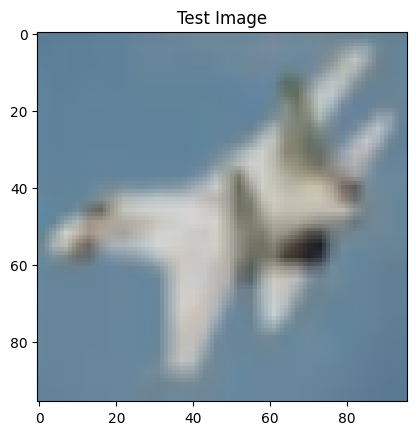

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: cat


In [30]:
plt.imshow(test_images[10])
plt.title("Test Image")
plt.show()

prediction = model.predict(test_images[10].numpy().reshape(1,96,96,3))

print("Predicted:", class_names[np.argmax(prediction)])

#Upload Your Own Image

In [32]:
from google.colab import files
uploaded = files.upload()

Saving shh.png to shh.png


#load Uploaded Image

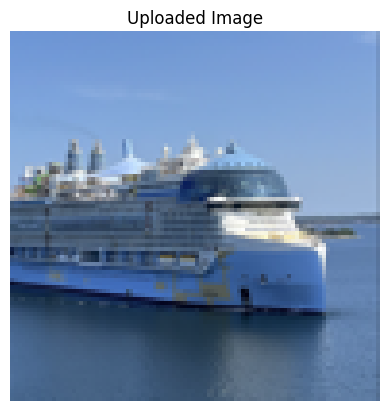

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(uploaded.keys())[0])
img = img.resize((96,96))

plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

#Predict Uploaded Image

In [34]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Show Multiple Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


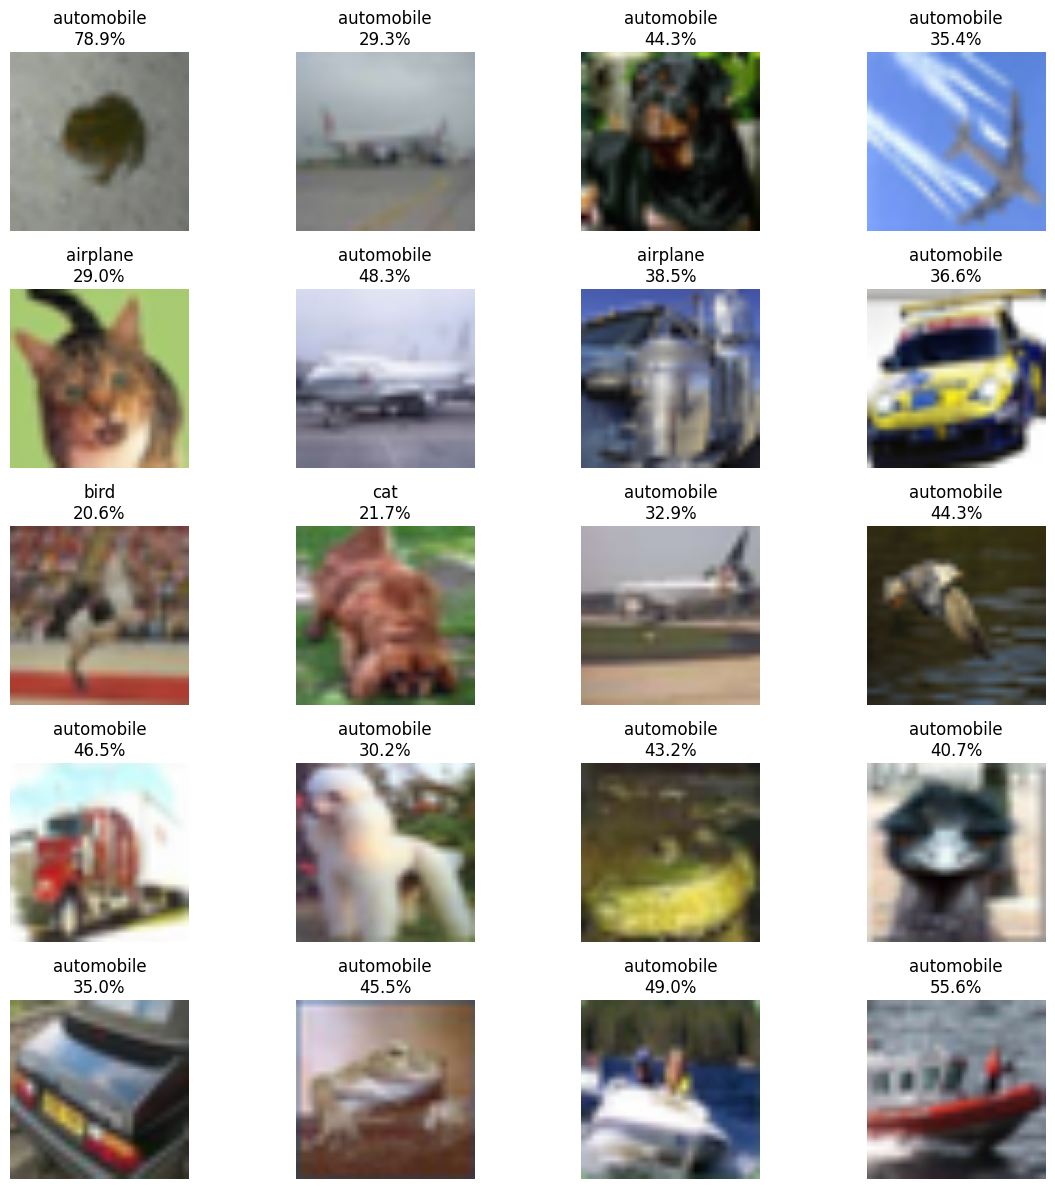

Final Prediction: automobile


In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# load CIFAR10 dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# normalize
test_images = test_images / 255.0

# resize to match your model
test_images = tf.image.resize(test_images,(96,96))

# class labels
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

plt.figure(figsize=(12,12))

for i in range(20):

    index = random.randint(0, len(test_images)-1)

    img = test_images[index]

    img_input = img.numpy().reshape(1,96,96,3)

    prediction = model.predict(img_input)

    scores = tf.nn.softmax(prediction[0])

    predicted_label = class_names[np.argmax(scores)]

    confidence = np.max(scores) * 100

    plt.subplot(5,4,i+1)
    plt.imshow(img)
    plt.title(f"{predicted_label}\n{confidence:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()
# final predicted class
predicted_class = class_names[np.argmax(prediction)]

print("Final Prediction:", predicted_class)

